# Empirical Covariance of Periodogram Ordinates — Independence Check

## 목적

Whittle / Debiased-Whittle likelihood는 서로 다른 주파수 $\omega_j \neq \omega_k$에서  
**periodogram ordinates $I_j$, $I_k$가 (점근적으로) 독립**이라고 가정한다.

실제 GEMS TCO 데이터(7월 2024)에서 이 가정이 얼마나 유효한지 확인한다.

$$\text{Cov}_{\text{emp}}(I_j, I_k) = \frac{1}{D}\sum_{d=1}^D (I_d(\omega_j) - \hat{f}_j)(I_d(\omega_k) - \hat{f}_k)$$

**Wick 기준선**: Hann taper만으로 생기는 coupling (stationary Gaussian field 가정)  
$$\text{Cov}_{\text{theo}}(I_j, I_k) \approx \hat{f}_j \hat{f}_k \cdot \frac{|F_{H^2}[j-k]|^2 + |F_{H^2}[j+k]|^2}{(MN)^2}$$

**핵심 질문**: $\text{Cov}_{\text{emp}} \gg \text{Cov}_{\text{theo}}$이면 taper 이상의 coupling 존재  
→ 독립성 가정 위반, 어느 주파수 대역에서 가장 심한가?

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fftn

# GEMS grid dimensions (July 2024, lat[-3,2], lon[121,131])
M, N   = 114, 159       # lat × lon
DLAT   = 0.044          # degrees/cell (lat)
DLON   = 0.063          # degrees/cell (lon)

# 2D Hann taper — power-preserving (||H||_F² / (M*N) = 1)
H = np.outer(np.hanning(M), np.hanning(N))
H /= np.sqrt(np.mean(H**2))

# Pre-compute DFT of H² once — used in Wick formula
F_H2 = fftn(H**2)

print(f"Grid: {M}×{N}  |  taper ||H||² / (MN) = {np.mean(H**2):.4f}  (should be 1.0)")

Grid: 114×159  |  taper ||H||² / (MN) = 1.0000  (should be 1.0)


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# Frequency selection: 3 bands × 3 frequencies = 9 total
#
# Grid: M=114 lat, N=159 lon  |  0.044°/cell lat,  0.063°/cell lon
# Spatial scale at index j:  λ_lat = M/j1 * DLAT,  λ_lon = N/j2 * DLON
#
# Band   j1 range   λ_lat           Physical meaning
# Low    1–3        1.7°–5.0°       domain-scale O3 gradient
# Mid    8–20       0.25°–0.62°     mesoscale variability
# High   30–55      0.09°–0.17°     small-scale / near Nyquist
# ─────────────────────────────────────────────────────────────────────────────

FREQ_BANDS = {
    "Low":  [(1,1),  (2,3),   (3,5)],
    "Mid":  [(8,13), (12,19), (18,28)],
    "High": [(35,55),(44,68), (54,77)],
}

FREQ_ALL    = []
BAND_LABELS = []
for band, freqs in FREQ_BANDS.items():
    for j in freqs:
        FREQ_ALL.append(j)
        BAND_LABELS.append(band)
K = len(FREQ_ALL)

print(f"{'#':>3}  {'Band':>6}  {'j=(j1,j2)':>12}  {'λ_lat (°)':>10}  {'λ_lon (°)':>10}")
print('-'*55)
for q, (j, band) in enumerate(zip(FREQ_ALL, BAND_LABELS)):
    lam_lat = M / j[0] * DLAT
    lam_lon = N / j[1] * DLON
    print(f"  {q:>2}  {band:>6}  ({j[0]:3d},{j[1]:3d})  {lam_lat:>12.3f}  {lam_lon:>12.3f}")

  #    Band     j=(j1,j2)   λ_lat (°)   λ_lon (°)
-------------------------------------------------------
   0     Low  (  1,  1)         5.016        10.017
   1     Low  (  2,  3)         2.508         3.339
   2     Low  (  3,  5)         1.672         2.003
   3     Mid  (  8, 13)         0.627         0.771
   4     Mid  ( 12, 19)         0.418         0.527
   5     Mid  ( 18, 28)         0.279         0.358
   6    High  ( 35, 55)         0.143         0.182
   7    High  ( 44, 68)         0.114         0.147
   8    High  ( 54, 77)         0.093         0.130


In [3]:
import sys
sys.path.append("/Users/joonwonlee/Documents/GEMS_TCO-1/src")

import torch
from GEMS_TCO.data_loader import load_data_dynamic_processed
from GEMS_TCO import configuration as config

lat_range_input = [-3, 2]
lon_range_input = [121, 131]

loader = load_data_dynamic_processed(config.mac_data_load_path)
df_map, _, _, monthly_mean = loader.load_maxmin_ordered_data_bymonthyear(
    lat_lon_resolution=[1, 1],
    mm_cond_number=8,
    years_=['2024'],
    months_=[7],
    lat_range=lat_range_input,
    lon_range=lon_range_input,
    is_whittle=True
)

N_DAYS = len(df_map) // 8
print(f"Loaded {N_DAYS} days  |  monthly_mean = {monthly_mean:.3f} DU")

# Build daily hourly maps
daily_hourly_maps = []
for day_idx in range(N_DAYS):
    day_map, _ = loader.load_working_data(
        df_map,
        monthly_mean=monthly_mean,
        idx_for_datamap=[day_idx * 8, day_idx * 8 + 8],
        ord_mm=None,
        dtype=torch.float64,
        keep_ori=False
    )
    daily_hourly_maps.append(day_map)

_k0 = list(daily_hourly_maps[0].keys())[0]
_t0 = daily_hourly_maps[0][_k0]
M_grid = len(torch.unique(_t0[:, 0]))
N_grid = len(torch.unique(_t0[:, 1]))
print(f"Grid: {M_grid} × {N_grid}  ({M_grid * N_grid} points)")

--- Global Monthly Mean for 2024-7: 257.9726 ---
Loaded 31 days  |  monthly_mean = 257.973 DU
Grid: 114 × 159  (18126 points)


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# Compute I_d(ω_j) for each day d:
#   - apply Hann taper → FFT → |F|²/(MN)
#   - average over 8 time slots within the day
# Result: I_mat[d, q] = mean periodogram at ω_{j_q} for day d
#         f_hat[q]    = mean over days  (empirical spectral density)
# ─────────────────────────────────────────────────────────────────────────────

# Re-build taper for actual grid size (in case it differs from M, N)
H_data  = np.outer(np.hanning(M_grid), np.hanning(N_grid))
H_data /= np.sqrt(np.mean(H_data**2))
F_H2_data = fftn(H_data**2)

I_mat = np.zeros((N_DAYS, K), dtype=float)

print(f"Computing periodograms: {N_DAYS} days × 8 slots × {K} frequencies...")
for d in range(N_DAYS):
    slot_vals = np.zeros((8, K), dtype=float)
    keys = sorted(daily_hourly_maps[d].keys())
    for s, key in enumerate(keys[:8]):
        t    = daily_hourly_maps[d][key]
        grid = np.nan_to_num(t[:, 2].numpy().reshape(M_grid, N_grid), nan=0.0)
        g    = (grid - grid.mean()) * H_data
        F    = fftn(g)
        I_field = np.abs(F)**2 / (M_grid * N_grid)
        for q, j in enumerate(FREQ_ALL):
            slot_vals[s, q] = I_field[j[0], j[1]]
    I_mat[d] = slot_vals.mean(axis=0)

f_hat = I_mat.mean(axis=0)   # (K,)

print(f"\n{'q':>3}  {'Band':>5}  {'freq':>12}  {'f̂_j':>12}  {'λ_lat':>8}  {'λ_lon':>8}")
print("  " + "-"*60)
for q, (j, band) in enumerate(zip(FREQ_ALL, BAND_LABELS)):
    lam_lat = M_grid / j[0] * DLAT
    lam_lon = N_grid / j[1] * DLON
    print(f"  {q:2d}  {band:5s}  ({j[0]:3d},{j[1]:3d})  {f_hat[q]:12.4f}   {lam_lat:.3f}°   {lam_lon:.3f}°")

Computing periodograms: 31 days × 8 slots × 9 frequencies...

  q   Band          freq          f̂_j     λ_lat     λ_lon
  ------------------------------------------------------------
   0  Low    (  1,  1)     4033.7495   5.016°   10.017°
   1  Low    (  2,  3)      458.4666   2.508°   3.339°
   2  Low    (  3,  5)      131.2148   1.672°   2.003°
   3  Mid    (  8, 13)       22.3991   0.627°   0.771°
   4  Mid    ( 12, 19)       10.7746   0.418°   0.527°
   5  Mid    ( 18, 28)        4.7712   0.279°   0.358°
   6  High   ( 35, 55)        1.9815   0.143°   0.182°
   7  High   ( 44, 68)        1.8531   0.114°   0.147°
   8  High   ( 54, 77)        1.6850   0.093°   0.130°


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# Empirical covariance  Cov_emp(I_j, I_k)
# ─────────────────────────────────────────────────────────────────────────────
I_centered = I_mat - f_hat                            # (D, K)
Cov_emp    = (I_centered.T @ I_centered) / N_DAYS     # (K, K) biased
var_emp    = np.diag(Cov_emp)
std_emp    = np.sqrt(np.clip(var_emp, 1e-30, None))
Corr_emp   = Cov_emp / np.outer(std_emp, std_emp)

# ─────────────────────────────────────────────────────────────────────────────
# Wick baseline  Cov_theo(I_j, I_k)  — taper-induced coupling only
# Cov_theo ≈ f̂_j · f̂_k · [|F_{H²}[j-k]|² + |F_{H²}[j+k]|²] / (MN)²
# ─────────────────────────────────────────────────────────────────────────────
MN2      = (M_grid * N_grid) ** 2
Cov_theo = np.zeros((K, K), dtype=float)
for i, j in enumerate(FREQ_ALL):
    for l, k in enumerate(FREQ_ALL):
        dm = ((j[0]-k[0]) % M_grid, (j[1]-k[1]) % N_grid)
        dp = ((j[0]+k[0]) % M_grid, (j[1]+k[1]) % N_grid)
        Cov_theo[i, l] = (
            f_hat[i] * f_hat[l] *
            (abs(F_H2_data[dm])**2 + abs(F_H2_data[dp])**2) / MN2
        )
var_theo  = np.diag(Cov_theo)
std_theo  = np.sqrt(np.clip(var_theo, 1e-30, None))
Corr_theo = Cov_theo / np.outer(std_theo, std_theo)

# Summary
print(f"D = {N_DAYS} days  |  K = {K} frequencies")
print(f"\n{'q':>3}  {'Band':>5}  {'freq':>12}  {'f̂_j':>10}  "
      f"{'Var_emp':>12}  {'Var_theo≈f̂²':>14}  {'Ratio':>8}")
print("  " + "-"*72)
for q, (j, band) in enumerate(zip(FREQ_ALL, BAND_LABELS)):
    ratio = var_emp[q] / var_theo[q] if var_theo[q] > 0 else float('nan')
    print(f"  {q:2d}  {band:5s}  ({j[0]:3d},{j[1]:3d})  "
          f"{f_hat[q]:10.4f}  {var_emp[q]:12.4f}  {var_theo[q]:14.4f}  {ratio:8.3f}")

D = 31 days  |  K = 9 frequencies

  q   Band          freq        f̂_j       Var_emp    Var_theo≈f̂²     Ratio
  ------------------------------------------------------------------------
   0  Low    (  1,  1)   4033.7495  9349702.7856   16285356.5967     0.574
   1  Low    (  2,  3)    458.4666   198946.4929     210191.6155     0.947
   2  Low    (  3,  5)    131.2148     9643.3240      17217.3194     0.560
   3  Mid    (  8, 13)     22.3991      219.9675        501.7212     0.438
   4  Mid    ( 12, 19)     10.7746       39.3122        116.0930     0.339
   5  Mid    ( 18, 28)      4.7712        3.2573         22.7644     0.143
   6  High   ( 35, 55)      1.9815        0.4251          3.9263     0.108
   7  High   ( 44, 68)      1.8531        0.8404          3.4338     0.245
   8  High   ( 54, 77)      1.6850        0.6566          2.8393     0.231


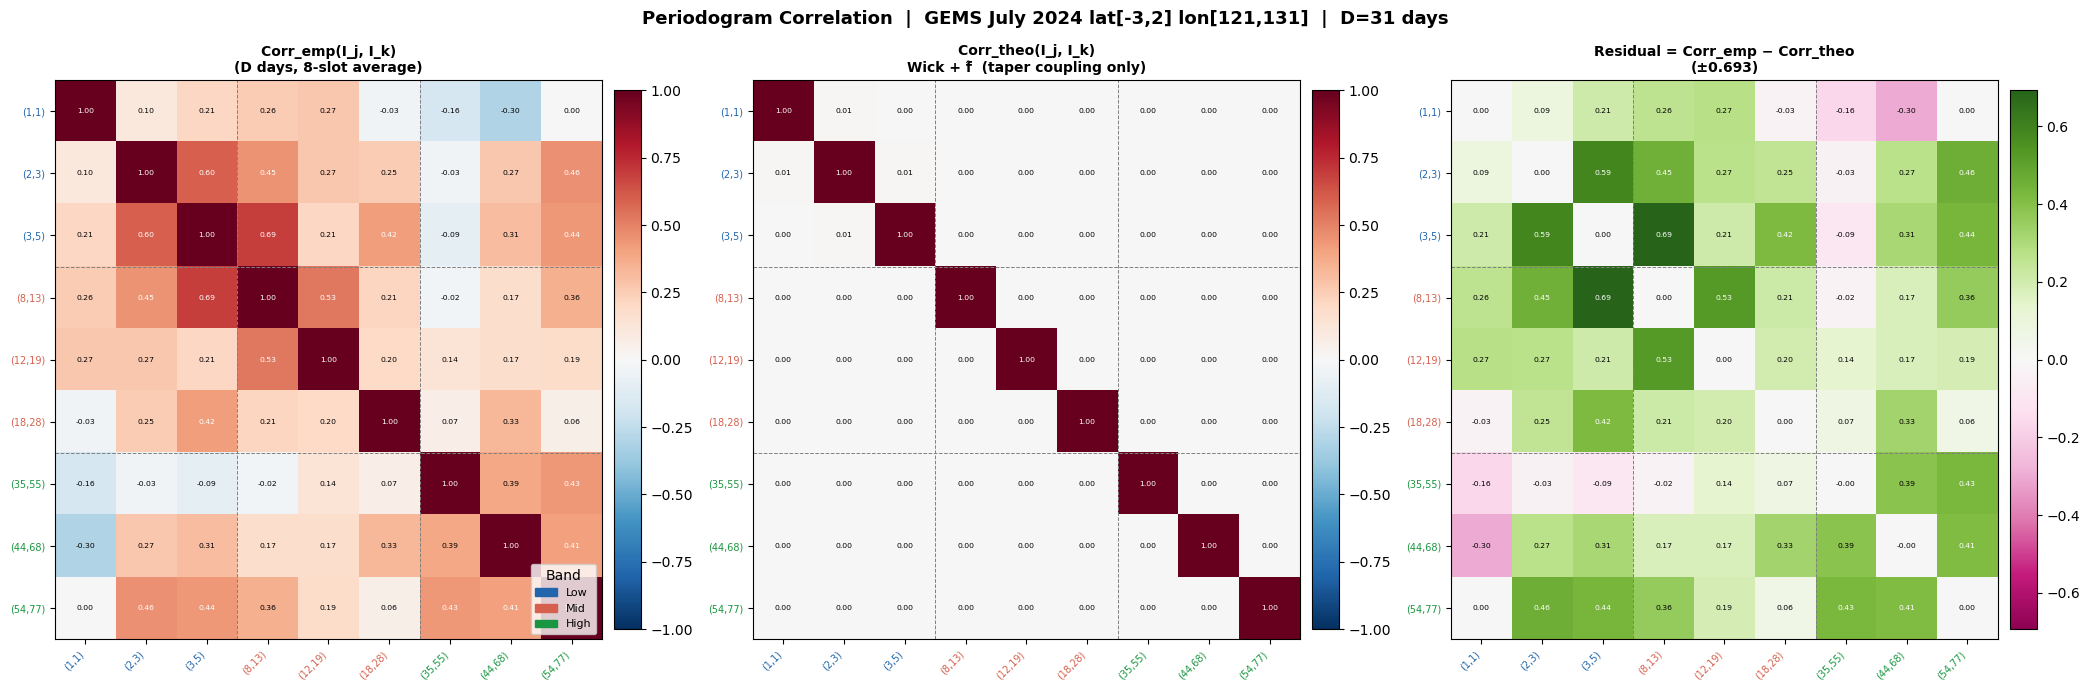

In [6]:
from matplotlib.patches import Patch

# ─────────────────────────────────────────────────────────────────────────────
# Main plot: Corr_emp | Corr_theo | Residual
# ─────────────────────────────────────────────────────────────────────────────
band_colors = {"Low": "#2166ac", "Mid": "#d6604d", "High": "#1a9641"}
tick_labels  = [f"({j[0]},{j[1]})" for j in FREQ_ALL]
tick_colors  = [band_colors[b] for b in BAND_LABELS]
SEP = [2.5, 5.5]

def style_ax(ax, mat, cmap, vmin, vmax, title):
    im = ax.imshow(mat, cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xticks(range(K)); ax.set_yticks(range(K))
    ax.set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=7)
    ax.set_yticklabels(tick_labels, fontsize=7)
    for q, tc in enumerate(tick_colors):
        ax.get_xticklabels()[q].set_color(tc)
        ax.get_yticklabels()[q].set_color(tc)
    for sep in SEP:
        ax.axhline(sep, color='gray', lw=0.7, ls='--')
        ax.axvline(sep, color='gray', lw=0.7, ls='--')
    for i in range(K):
        for l in range(K):
            ax.text(l, i, f"{mat[i,l]:.2f}", ha='center', va='center',
                    fontsize=5.5,
                    color='white' if abs(mat[i,l]) > 0.4 else 'black')

fig, axes = plt.subplots(1, 3, figsize=(21, 7))
fig.suptitle(
    f"Periodogram Correlation  |  GEMS July 2024 lat[-3,2] lon[121,131]  |  D={N_DAYS} days",
    fontsize=13, fontweight='bold')

style_ax(axes[0], Corr_emp,  'RdBu_r', -1, 1,
         "Corr_emp(I_j, I_k)\n(D days, 8-slot average)")
style_ax(axes[1], Corr_theo, 'RdBu_r', -1, 1,
         "Corr_theo(I_j, I_k)\nWick + f̂  (taper coupling only)")
residual = Corr_emp - Corr_theo
rlim = max(0.05, np.abs(residual).max())
style_ax(axes[2], residual, 'PiYG', -rlim, rlim,
         f"Residual = Corr_emp − Corr_theo\n(±{rlim:.3f})")

handles = [Patch(color=c, label=b) for b, c in band_colors.items()]
axes[0].legend(handles=handles, loc='lower right', fontsize=8, title='Band')

plt.tight_layout()
plt.savefig('/tmp/cov_periodogram_corr.png', dpi=130, bbox_inches='tight')
plt.show()

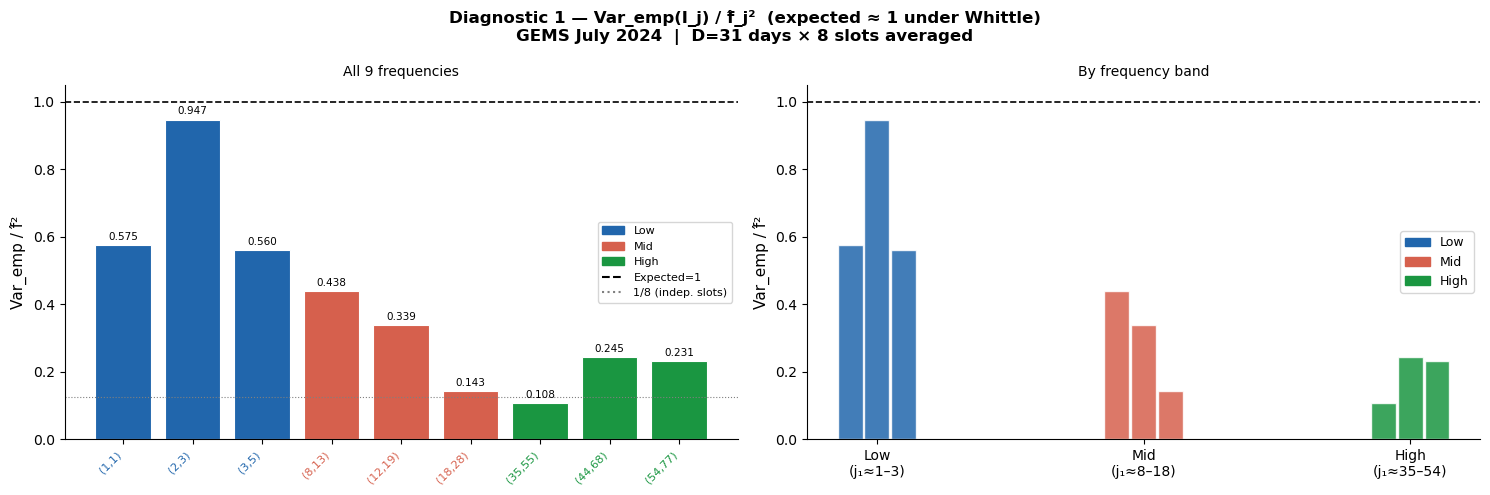

Var_emp / f̂²:
  ✓  Low    (  1,  1)  0.5746
  ✓  Low    (  2,  3)  0.9465
  ✓  Low    (  3,  5)  0.5601
  ⚠  Mid    (  8, 13)  0.4384
  ⚠  Mid    ( 12, 19)  0.3386
  ⚠  Mid    ( 18, 28)  0.1431
  ⚠  High   ( 35, 55)  0.1083
  ⚠  High   ( 44, 68)  0.2447
  ⚠  High   ( 54, 77)  0.2313


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# Diagnostic 1 — Diagonal: Var_emp(I_j) / f̂_j²
#   ≈ 1.0  →  I_j ~ Exp(f̂_j)  (Whittle assumption holds)
#   >> 1   →  over-dispersed (non-stationarity / day-to-day variability)
#   << 1   →  under-dispersed (averaging 8 slots shrinks variance)
# ─────────────────────────────────────────────────────────────────────────────
diag_ratio = var_emp / (f_hat**2)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle(
    f"Diagnostic 1 — Var_emp(I_j) / f̂_j²  (expected ≈ 1 under Whittle)\n"
    f"GEMS July 2024  |  D={N_DAYS} days × 8 slots averaged",
    fontsize=12, fontweight='bold')

cols = [band_colors[b] for b in BAND_LABELS]

ax = axes[0]
ax.bar(range(K), diag_ratio, color=cols, edgecolor='white', linewidth=0.8)
ax.axhline(1.0, color='black', lw=1.2, ls='--', label='Expected = 1.0')
ax.axhline(1.0/8, color='gray', lw=0.8, ls=':', label='1/8 (if slots independent)')
ax.set_xticks(range(K))
ax.set_xticklabels([f"({j[0]},{j[1]})" for j in FREQ_ALL], rotation=45, ha='right', fontsize=8)
for q, tc in enumerate(tick_colors):
    ax.get_xticklabels()[q].set_color(tc)
for i, v in enumerate(diag_ratio):
    ax.text(i, v + 0.01 * diag_ratio.max(), f"{v:.3f}", ha='center', va='bottom', fontsize=7.5)
ax.set_ylabel("Var_emp / f̂²", fontsize=11)
ax.set_title("All 9 frequencies", fontsize=10)
handles_band = [Patch(color=c, label=b) for b, c in band_colors.items()]
ax.legend(handles=handles_band + [
    plt.Line2D([0],[0], color='black', ls='--', label='Expected=1'),
    plt.Line2D([0],[0], color='gray',  ls=':',  label='1/8 (indep. slots)')
], fontsize=8)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

ax = axes[1]
BANDS_IDX = {"Low": [0,1,2], "Mid": [3,4,5], "High": [6,7,8]}
for band_name, band_indices in BANDS_IDX.items():
    vals = [diag_ratio[q] for q in band_indices]
    x_ = [band_indices[0] + i*0.3 for i in range(3)]
    ax.bar(x_, vals, width=0.28, color=band_colors[band_name], edgecolor='white', alpha=0.85)
ax.set_xticks([0.3, 3.3, 6.3])
ax.set_xticklabels(['Low\n(j₁≈1–3)', 'Mid\n(j₁≈8–18)', 'High\n(j₁≈35–54)'], fontsize=10)
ax.axhline(1.0, color='black', lw=1.2, ls='--')
ax.set_ylabel("Var_emp / f̂²", fontsize=11)
ax.set_title("By frequency band", fontsize=10)
ax.legend(handles=handles_band, fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('/tmp/cov_diag_ratio.png', dpi=130, bbox_inches='tight')
plt.show()

print("Var_emp / f̂²:")
for q, (j, band) in enumerate(zip(FREQ_ALL, BAND_LABELS)):
    flag = "✓" if 0.5 < diag_ratio[q] < 2.0 else "⚠"
    print(f"  {flag}  {band:5s}  ({j[0]:3d},{j[1]:3d})  {diag_ratio[q]:.4f}")

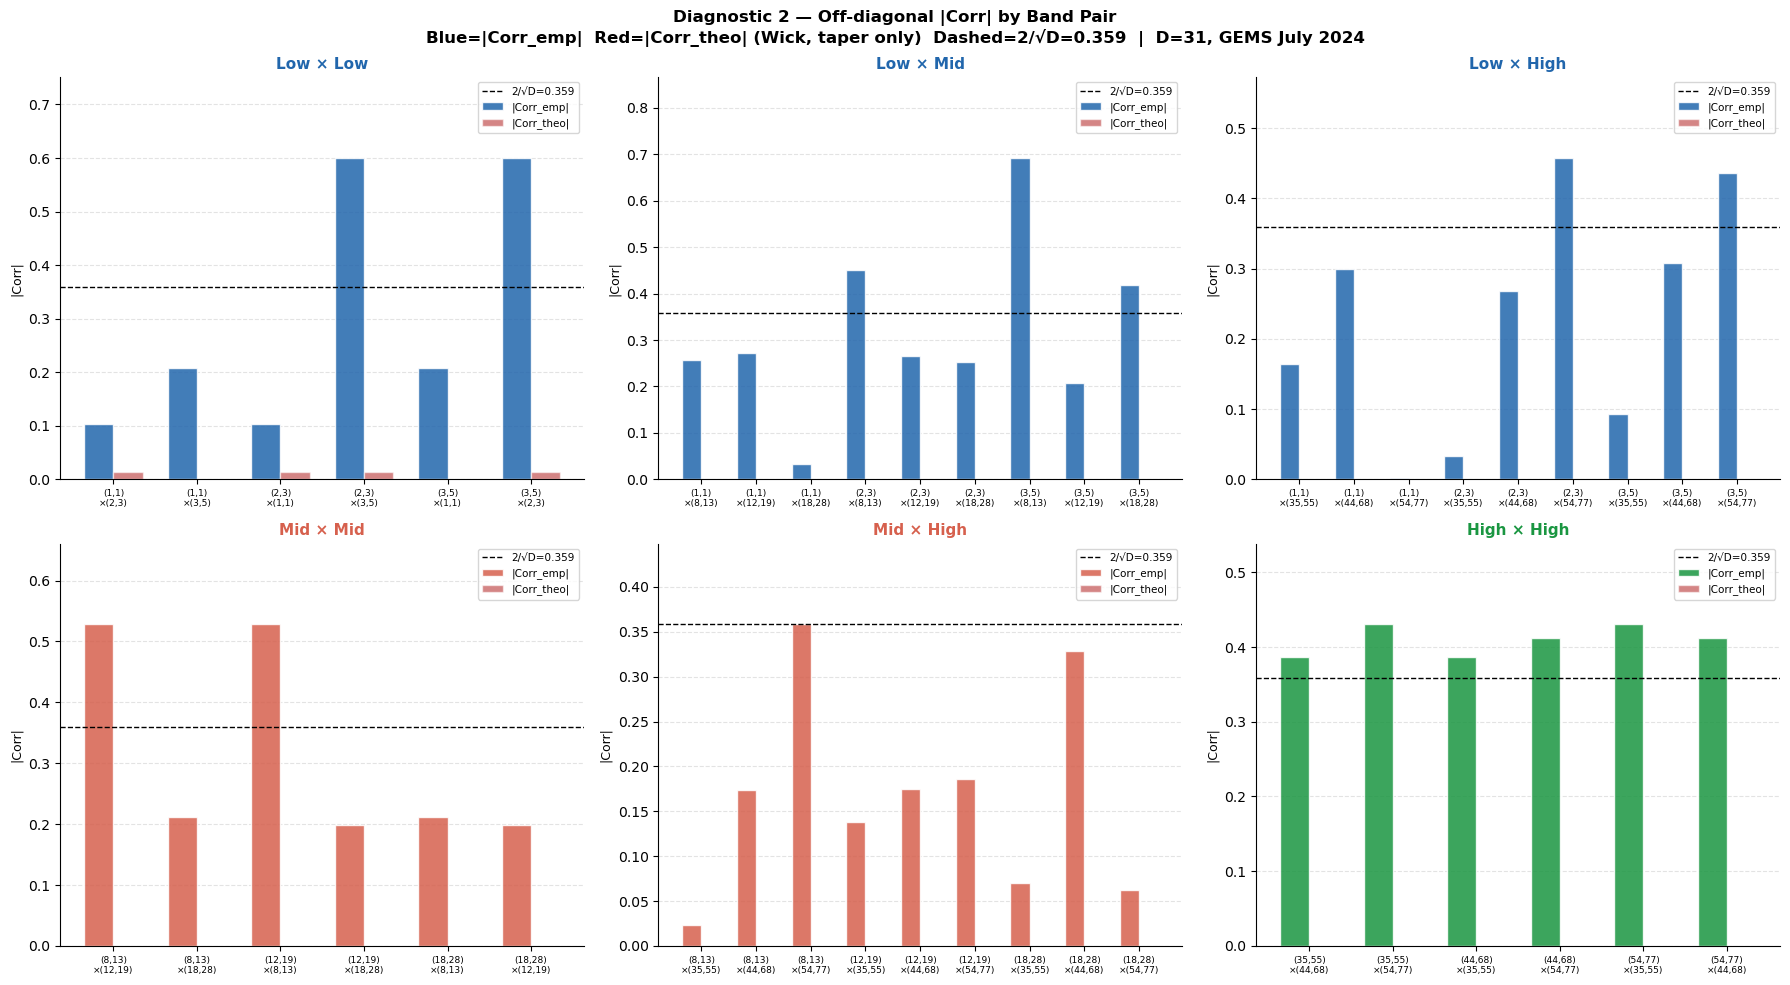


2/√D = 0.3592  (significance threshold)

     Band pair    max|Corr_emp|   max|Corr_theo|     n_sig/n
------------------------------------------------------------
  ⚠ Low  ×Low             0.6009           0.0132  2/6
  ⚠ Low  ×Mid             0.6931           0.0000  3/9
  ⚠ Low  ×High            0.4582           0.0000  2/9
  ⚠ Mid  ×Mid             0.5285           0.0000  2/6
    Mid  ×High            0.3585           0.0000  0/9
  ⚠ High ×High            0.4306           0.0000  6/6


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# Diagnostic 2 — Off-diagonal: |Corr_emp| vs |Corr_theo| by band pair
#
# If |Corr_emp| >> |Corr_theo|: real data has coupling beyond taper artifact
#   → Whittle independence assumption violated at this band pair
# If |Corr_emp| ≈ |Corr_theo|: independence approximately holds
# ─────────────────────────────────────────────────────────────────────────────
BAND_PAIRS = [("Low","Low"),("Low","Mid"),("Low","High"),
              ("Mid","Mid"),("Mid","High"),("High","High")]
sig_thresh = 2 / np.sqrt(N_DAYS)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(
    f"Diagnostic 2 — Off-diagonal |Corr| by Band Pair\n"
    f"Blue=|Corr_emp|  Red=|Corr_theo| (Wick, taper only)  "
    f"Dashed=2/√D={sig_thresh:.3f}  |  D={N_DAYS}, GEMS July 2024",
    fontsize=12, fontweight='bold')
axes = axes.ravel()

summary_rows = []
for ax_idx, (b1, b2) in enumerate(BAND_PAIRS):
    ax = axes[ax_idx]
    idx1 = BANDS_IDX[b1]
    idx2 = BANDS_IDX[b2]
    pairs_emp, pairs_theo, pair_labels = [], [], []
    for i in idx1:
        for l in idx2:
            if b1 == b2 and i == l:
                continue
            pairs_emp.append(abs(Corr_emp[i, l]))
            pairs_theo.append(abs(Corr_theo[i, l]))
            pair_labels.append(f"({FREQ_ALL[i][0]},{FREQ_ALL[i][1]})\n×({FREQ_ALL[l][0]},{FREQ_ALL[l][1]})")

    x = np.arange(len(pairs_emp))
    w = 0.35
    ax.bar(x - w/2, pairs_emp,  width=w, color=band_colors[b1],  alpha=0.85, edgecolor='white', label='|Corr_emp|')
    ax.bar(x + w/2, pairs_theo, width=w, color='firebrick', alpha=0.55, edgecolor='white', label='|Corr_theo|')
    ax.axhline(sig_thresh, color='black', ls='--', lw=1.0, label=f'2/√D={sig_thresh:.3f}')
    ax.set_title(f"{b1} × {b2}", fontsize=11, fontweight='bold', color=band_colors[b1])
    ax.set_xticks(x)
    ax.set_xticklabels(pair_labels, fontsize=6.5)
    ax.set_ylabel("|Corr|", fontsize=9)
    ax.set_ylim(0, max(0.05, max(pairs_emp + pairs_theo) * 1.25))
    ax.legend(fontsize=7.5)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.yaxis.grid(True, ls='--', alpha=0.35); ax.set_axisbelow(True)

    n_sig = sum(v > sig_thresh for v in pairs_emp)
    summary_rows.append((b1, b2, max(pairs_emp), max(pairs_theo), n_sig, len(pairs_emp)))

plt.tight_layout()
plt.savefig('/tmp/cov_offdiag_by_band.png', dpi=130, bbox_inches='tight')
plt.show()

print(f"\n2/√D = {sig_thresh:.4f}  (significance threshold)")
print(f"\n{'Band pair':>14}  {'max|Corr_emp|':>15}  {'max|Corr_theo|':>15}  {'n_sig/n':>10}")
print("-"*60)
for b1, b2, me, mt, ns, np_ in summary_rows:
    flag = "⚠" if me > sig_thresh else " "
    print(f"  {flag} {b1:5s}×{b2:5s}  {me:>15.4f}  {mt:>15.4f}  {ns}/{np_}")